In [1]:
#Program: A)  Support Vector Machine (SVM) and Logistic Regression
# DATASET: Iris Dataset
# Step 1: Import Required Libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

In [13]:
# Set plot style
sns.set_theme(style="whitegrid")
# Step 2: Load Dataset
iris = pd.read_csv("/content/Iris.csv")
print("First Five Records")
print(iris.head())
print("\nDataset Shape")
print(iris.shape)
print("\nDataset Information")
print(iris.info())
print("\nClass Distribution")
print(iris["Species"].value_counts())

First Five Records
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape
(150, 6)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4)

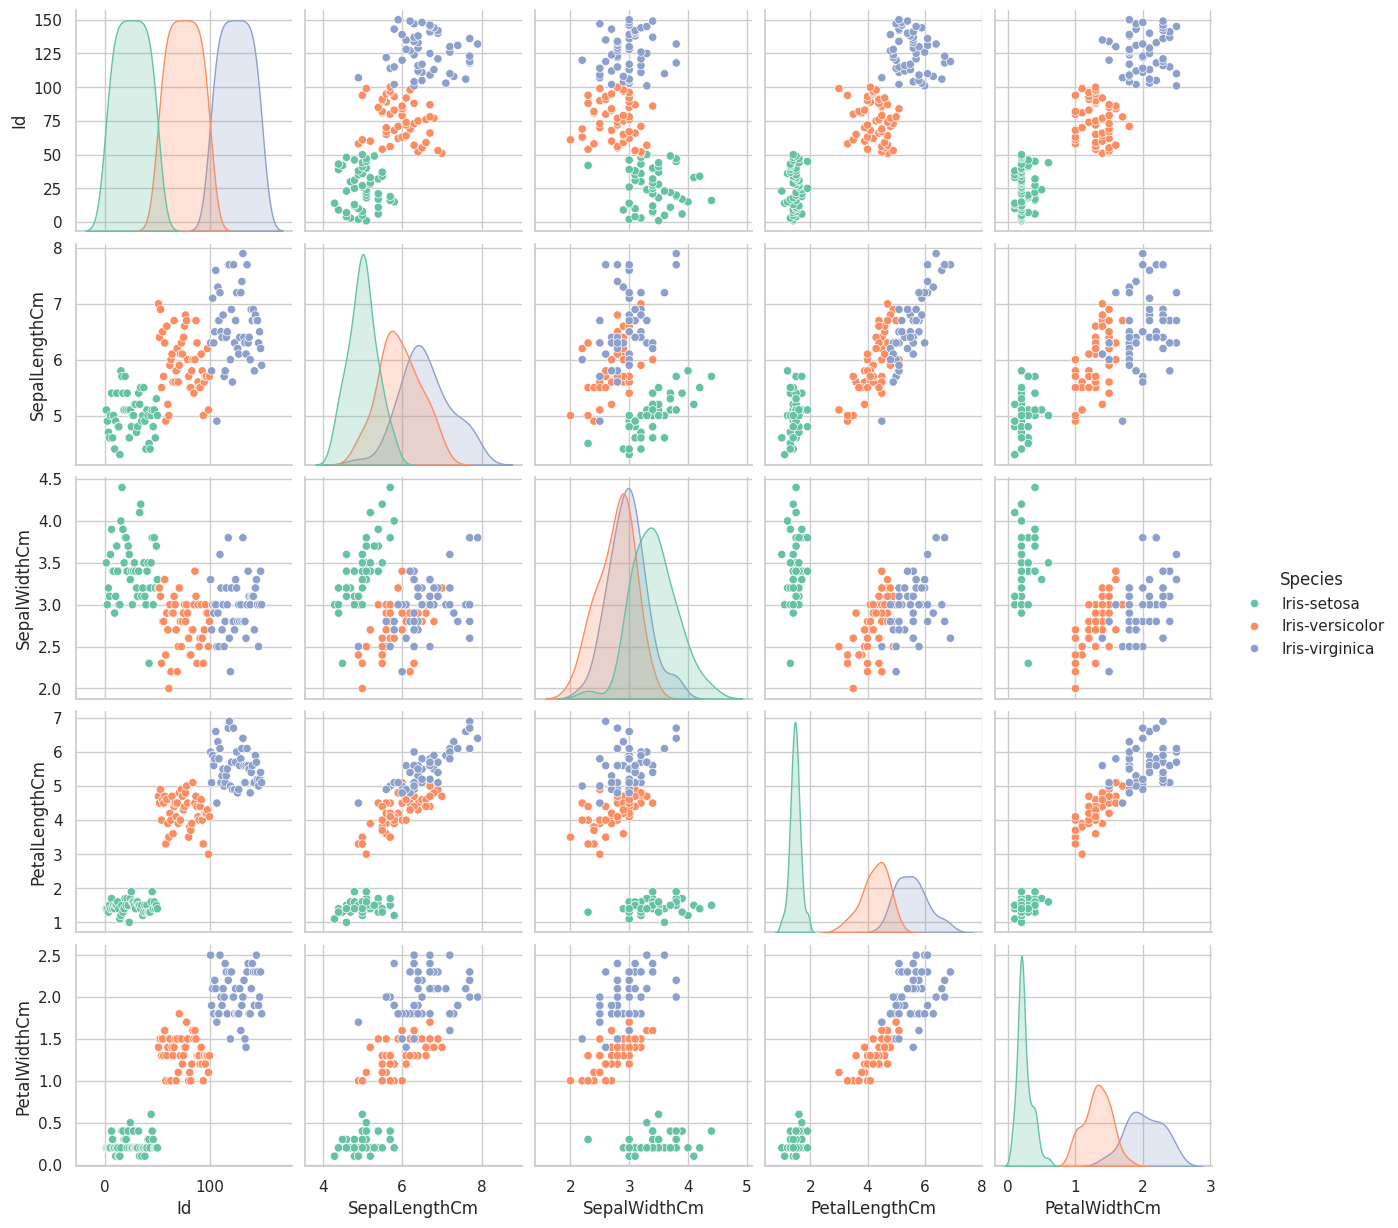


Training Samples : 105
Testing Samples  : 45


In [14]:
# Step 3: Data Visualization
sns.pairplot(data=iris, hue="Species", palette="Set2")
plt.show()

# Step 4: Split Dataset
X = iris.drop(columns=["Species"])
y = iris["Species"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)
print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

In [15]:
# Step 5: Support Vector Machine
print("\n====================================")
print("SUPPORT VECTOR MACHINE")
print("====================================")
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train, y_train)


svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("Accuracy :", round(svm_accuracy * 100, 2), "%")
print("\nConfusion Matrix")
print(confusion_matrix(y_test, svm_pred))
print("\nClassification Report")
print(classification_report(y_test, svm_pred))


SUPPORT VECTOR MACHINE
Accuracy : 100.0 %

Confusion Matrix
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



In [16]:
# Step 6: Logistic Regression
print("\n====================================")
print("LOGISTIC REGRESSION")
print("====================================")
lr_model = LogisticRegression(
    max_iter=200,
    random_state=42
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Accuracy :", round(lr_accuracy * 100, 2), "%")
print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))
print("\nClassification Report")
print(classification_report(y_test, lr_pred))


LOGISTIC REGRESSION
Accuracy : 100.0 %

Confusion Matrix
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
# Step 7: Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Support Vector Machine",
        "Logistic Regression"
    ],
    "Accuracy (%)": [
        round(svm_accuracy * 100, 2),
        round(lr_accuracy * 100, 2)
    ]
})
print("\n====================================")
print("MODEL COMPARISON")
print("====================================")
print(comparison)


MODEL COMPARISON
                    Model  Accuracy (%)
0  Support Vector Machine         100.0
1     Logistic Regression         100.0


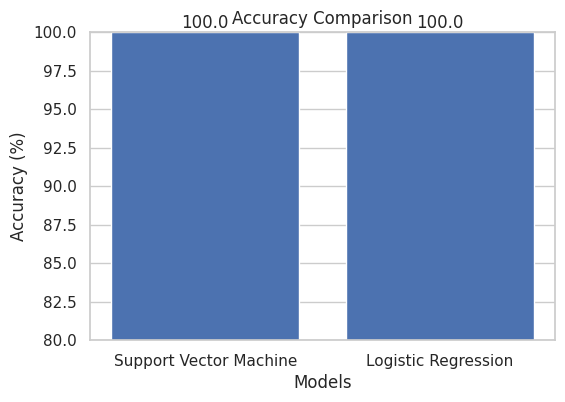

In [18]:
# Step 8: Accuracy Comparison Graph
plt.figure(figsize=(6,4))
plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(80,100)
for i, value in enumerate(comparison["Accuracy (%)"]):
    plt.text(i, value+0.3, str(value), ha='center')
plt.show()

In [19]:
# Step 9: Predict a New Sample
sample = X_test.iloc[[0]]
print("\n====================================")
print("NEW SAMPLE PREDICTION")
print("====================================")
print("Actual Class :", y_test.iloc[0])
print("SVM Prediction :", svm_model.predict(sample)[0])
print("Logistic Regression Prediction :", lr_model.predict(sample)[0])


NEW SAMPLE PREDICTION
Actual Class : Iris-versicolor
SVM Prediction : Iris-versicolor
Logistic Regression Prediction : Iris-versicolor


In [22]:
#Program B) SVM Kernel Comparison
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [23]:
# ==========================================================
# Generate Dataset
# ==========================================================

X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
# ==========================================================
# Split Dataset
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [24]:
# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# Train Models
# ==========================================================

linear_model = SVC(kernel='linear', C=1)
rbf_model     = SVC(kernel='rbf', gamma='scale', C=1)
poly_model   = SVC(kernel='poly', degree=3, C=1)

linear_model.fit(X_train, y_train)
rbf_model.fit(X_train, y_train)
poly_model.fit(X_train, y_train)

# ==========================================================
# Predictions
# ==========================================================

linear_pred = linear_model.predict(X_test)
rbf_pred = rbf_model.predict(X_test)
poly_pred = poly_model.predict(X_test)

In [25]:
# ==========================================================
# Accuracy
# ==========================================================

linear_acc = accuracy_score(y_test, linear_pred)
rbf_acc = accuracy_score(y_test, rbf_pred)
poly_acc = accuracy_score(y_test, poly_pred)

print("Linear Kernel Accuracy :", round(linear_acc*100, 2), "%")
print("RBF Kernel Accuracy    :", round(rbf_acc*100, 2), "%")
print("Polynomial Accuracy    :", round(poly_acc*100, 2), "%")

Linear Kernel Accuracy : 87.78 %
RBF Kernel Accuracy    : 90.0 %
Polynomial Accuracy    : 88.89 %


In [26]:
# ==========================================================
# Decision Boundary Function
# ==========================================================

def plot_boundary(model, title, subplot):
    plt.subplot(subplot)

    x_min, x_max = X_train[:, 0].min()-1, X_train[:, 0].max()+1
    y_min, y_max = X_train[:, 1].min()-1, X_train[:, 1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.35, cmap='coolwarm')
    plt.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        edgecolors='k',
        cmap='coolwarm'
    )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

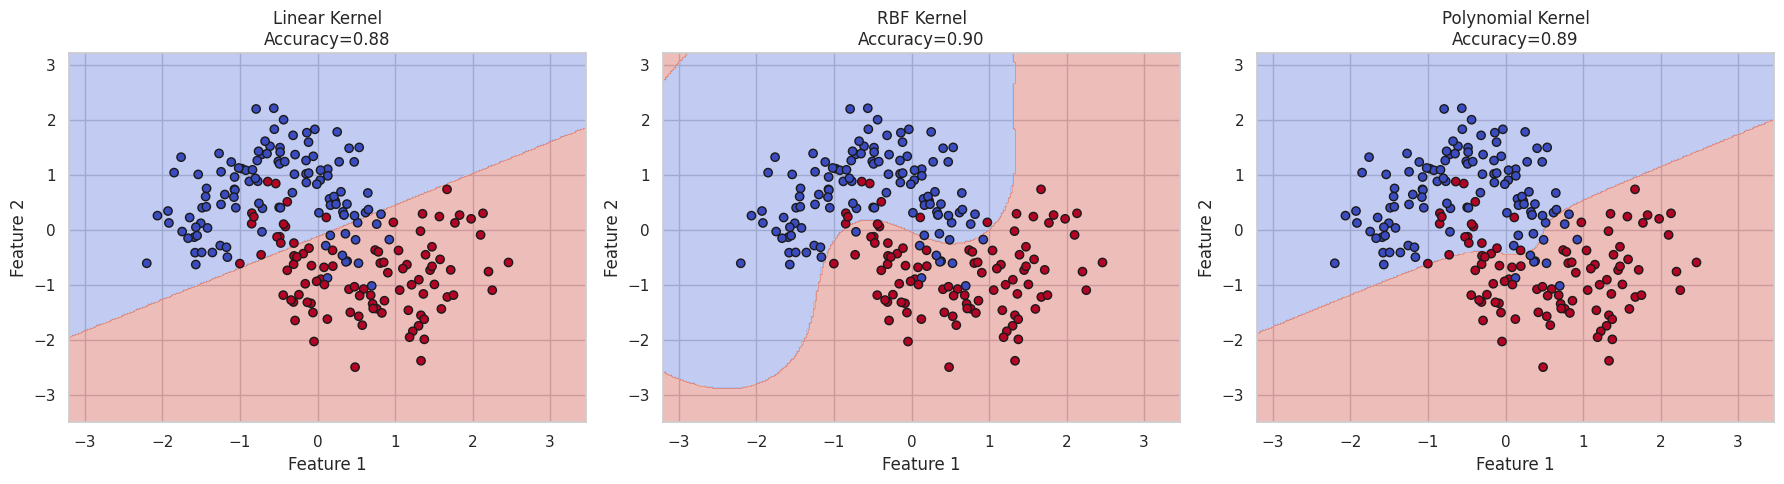

In [27]:
# ==========================================================
# Visualization
# ==========================================================

plt.figure(figsize=(18, 5))
plot_boundary(linear_model, f"Linear Kernel\nAccuracy={linear_acc:.2f}", 131)
plot_boundary(rbf_model, f"RBF Kernel\nAccuracy={rbf_acc:.2f}", 132)
plot_boundary(poly_model,    f"Polynomial Kernel\nAccuracy={poly_acc:.2f}", 133)
plt.tight_layout()
plt.show()